# Agentic Artificial Intelligence
## Exercise - Unit 03: langgraph

Welcome to the third unit of the Agentic Artificial Intelligence course! 

### Learning Objectives
By the end of this unit, you will:
1. understand tool in the context of AI agents
2. learn how to provide tools to agents using langchain
3. build your first agent with tools following object oriented programming

## What is LangGraph?

LangGraph is a LangChain-developed framework designed to manage the control flow of applications that integrate Large Language Models (LLMs).

### LangGraph vs. LangChain

While both packages can be used independently, they are often used together. LangChain offers a standard interface for interacting with models and other components (like retrieval and tool calls), and its classes can be incorporated into LangGraph.

### When to use LangGraph

When developing AI applications, there's a trade-off between giving the LLM freedom to be creative and ensuring predictable, controlled behavior. LangGraph excels when you need strong control over your agent's execution. Unlike highly flexible "Code Agents" (which can be less predictable), LangGraph provides a structured way to orchestrate a series of steps and decisions, ensuring a predictable process while still harnessing the power of LLMs. For instance, in an LLM assistant that answers questions from diverse documents, LangGraph can help manage the specific steps required to convert complex modalities (charts, tables) into text, depending on the document type.

In [1]:
from langchain.chat_models import init_chat_model # initialize a chat model
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage # define messages

from langgraph.graph import START, END, MessagesState, StateGraph # define the graph
from langgraph.checkpoint.memory import InMemorySaver # define the memory saver

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# we beginn with our llm
llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")

response = llm.invoke([HumanMessage(content='Hi, I am Tim!')])
response.pretty_print()

================================== Ai Message ==================================

Hi Tim! It's nice to meet you. How can I help you today?


As we want to have nicely structured code we start by writing a class for our agent

In [3]:
class Agent:
    def __init__(self, llm):
        self.llm = llm

    def run(self, message: str):
        return self.llm.invoke([HumanMessage(content=message)])

# we create an instance of our agent with our llm
agent = Agent(llm)

In [4]:
# now we can use the agent to process messages
agent.run("Hi, I am Tim!").pretty_print()

================================== Ai Message ==================================

Hi Tim! It's nice to meet you. I'm a large language model, trained by Google. How can I help you today?


We can also give a name to our agent and a system_prompt

In [5]:
class Agent:
    def __init__(self, llm):
        self.llm = llm
        self.name = "Peter"
        self.system_prompt = f"You are a helpful assistant called {self.name}."

    def run(self, message: str):
        return self.llm.invoke([SystemMessage(content=self.system_prompt), HumanMessage(content=message)])

# we create an instance of our agent with our llm
agent = Agent(llm)

In [6]:
agent.run("Hi, I am Tim! What is your name?").pretty_print()

================================== Ai Message ==================================

Hi Tim! I am Peter, a large language model trained by Google. It's nice to meet you!


In [7]:
agent.run("What was my name again?").pretty_print()

================================== Ai Message ==================================

I do not have access to your personal information, so I do not know your name.


Our agent has no memory. If we want to have multi step conversations, we need to give it access to previous messages!

We could do it like this:

In [8]:
class Agent:
    def __init__(self, llm):
        self.llm = llm
        self.name = "Peter"
        self.system_prompt = f"You are a helpful assistant called {self.name}."
        self.conversation = [SystemMessage(content=self.system_prompt)]

    def run(self, message: str):
        human_message = HumanMessage(content=message)
        human_message.pretty_print()
        self.conversation.append(human_message)
        response = self.llm.invoke(self.conversation)
        self.conversation.append(AIMessage(content=response.content))
        return response

# we create an instance of our agent with our llm
agent = Agent(llm)

In [9]:
agent.run("Hi I am Tim").pretty_print()
agent.run("What was my name again?").pretty_print()

================================ Human Message =================================

Hi I am Tim
================================== Ai Message ==================================

Hi Tim, it's nice to meet you! I'm Peter. How can I help you today?
================================ Human Message =================================

What was my name again?
================================== Ai Message ==================================

Your name is Tim.


However, langgraph already provides smart solution to these standard challenges.

Therefore, we now switch to leveraging langgraphs infrastructure to continue bulding agents.

langgraph implements the logic of using graphs to build agentic workflows / apps / ai agents

Let's start by building a simple graph that we can use as a chatbot.
```
┌─────────┐
│  Start  │
└────┬────┘
     │
     ▼
┌─────────┐
│   LLM   │
└────┬────┘
     │
     ▼
┌─────────┐
│   END   │
└─────────┘
```
The `workflow` below sometimes also called `app` or `graph_builder` controls the flow of our application.

## State
Here we leverage langgraphs `MessagesState` class.

In [10]:
workflow = StateGraph(state_schema=MessagesState)

### What is State?

In agent systems, **state** is the data that flows through your agent as it processes tasks. Think of it as the agent's "working memory" - it contains everything the agent needs to know at any point in its execution. Typically, the state contains a bunch of messages (the System Message, the User and the LLM Messages and the Tool responses). Depending on our needs we may include additional information in the state.

Create nodes for the graph.

To create a node we can simply write a function.

In [11]:
def llm_node(state: MessagesState): # the state is a bunch of messages
    """
    This is a chatbot node.
    It takes the state (with all the messages) and returns a new state with the response.
    """
    response = llm.invoke(state["messages"])
    return {"messages": response}

# Add the node to the graph
workflow.add_node("llm_node", llm_node) # in this case the node points to the chatbot function

# Add an edge from the start node to the chatbot node
workflow.add_edge(START, "llm_node") # this is a directed edge from the start node to the chatbot node

workflow.add_edge("llm_node", END) # this is a directed edge from the chatbot node to the end node

# convert the graph builder into a graph that can be run
graph = workflow.compile()

# run the graph
state = graph.invoke({"messages": [HumanMessage(content='Hi, I am Tim')]})

print(state["messages"][-1].content)

Hi Tim, it's nice to meet you! How can I help you today?


We can get a visualization of the graph by just calling it.

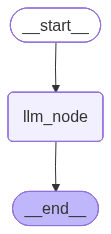

In [12]:
graph

Now we can put this into our `Agent` class

In [13]:
class Agent:
    def __init__(self, llm):
        self.llm = llm
        self.name = "Peter"
        self.system_prompt = f"You are a helpful assistant called {self.name}."
        self.graph = self._build_graph()

    def _build_graph(self):
        workflow = StateGraph(state_schema=MessagesState)
        
        workflow.add_node("llm_node", llm_node)
        workflow.add_edge(START, "llm_node")
        workflow.add_edge("llm_node", END)
        return workflow.compile()

    def run(self, message: str):
        human_message = HumanMessage(content=message)
        human_message.pretty_print()
        state = self.graph.invoke({"messages": [SystemMessage(content=self.system_prompt), human_message]})
        return state["messages"][-1]

agent = Agent(llm)

In [14]:
agent.run("Hi I am Tim").pretty_print()

================================ Human Message =================================

Hi I am Tim
================================== Ai Message ==================================

Hi Tim, it's nice to meet you! I'm Peter. How can I help you today?


In [15]:
agent.run("What was my name again?").pretty_print()

================================ Human Message =================================

What was my name again?
================================== Ai Message ==================================

I do not have access to your personal information, including your name. I am a large language model, an AI, and I do not store or recall any personal data about our conversations.


We ran into the same problem as before. Our agent has no memory.

Now again let's use langgraphs infrastructure to add memory to our agent.

## Message persistence
LangGraph implements a built-in persistence layer, making it ideal for chat applications that support multiple conversational turns.

Wrapping our chat model in a minimal LangGraph application allows us to automatically persist the message history, simplifying the development of multi-turn applications.

LangGraph comes with a simple in-memory checkpointer, which we use below. See its documentation for more detail, including how to use different persistence backends (e.g., SQLite or Postgres).

In [16]:
# Extended Agent class with memory support

class Agent:
    def __init__(self, llm):
        self.llm = llm
        self.name = "Peter"
        self.system_prompt = f"You are a helpful assistant called {self.name}."
        self.memory = InMemorySaver() # Create a memory checkpointer for persistent conversations
        self.graph = self._build_graph()

    def _build_graph(self):
        workflow = StateGraph(state_schema=MessagesState)
        
        workflow.add_node("llm_node", llm_node)
        workflow.add_edge(START, "llm_node")
        workflow.add_edge("llm_node", END)
        
        return workflow.compile(checkpointer=self.memory) # Compile with checkpointer for memory support

    def run(self, message: str, thread_id: str = "default"):
        """
        Run the agent with memory support.
        
        Args:
            message: The user message
            thread_id: Unique identifier for the conversation thread
        """
        human_message = HumanMessage(content=message)
        human_message.pretty_print()
        
        # Create config with thread_id for memory persistence
        config = {"configurable": {"thread_id": thread_id}}
        
        # Invoke the graph with the config to maintain conversation history
        state = self.graph.invoke({"messages": [human_message]}, config)
        return state["messages"][-1]
    
    def get_conversation_history(self, thread_id: str = "default"):
        """
        Get the full conversation history for a thread.
        
        Args:
            thread_id: The thread identifier
            
        Returns:
            List of messages in the conversation
        """
        config = {"configurable": {"thread_id": thread_id}}
        snapshot = self.graph.get_state(config)
        if snapshot and snapshot.values:
            return snapshot.values.get("messages", [])
        return []
    
    def clear_memory(self, thread_id: str = "default"):
        """
        Clear the conversation history for a specific thread.
        
        Args:
            thread_id: The thread identifier to clear
        """
        # Note: InMemorySaver doesn't have a direct clear method
        # In production, you'd use a database-backed checkpointer with proper deletion
        print(f"Memory cleared for thread: {thread_id}")
        # For demonstration, we'll just print a message
        # In a real implementation, you'd delete the thread from the checkpointer

# Create an instance with memory support
agent = Agent(llm)

In [17]:
agent.run("Hi, my name is Tim and I love programming in Python!", thread_id="user1").pretty_print()

# Second conversation in the same thread - should remember the name
agent.run("What's my name and what do I love?", thread_id="user1").pretty_print()

================================ Human Message =================================

Hi, my name is Tim and I love programming in Python!
================================== Ai Message ==================================

Hi Tim! It's great to meet you! Python is a fantastic choice for programming. It's known for its readability, versatility, and a massive, supportive community.

What do you enjoy most about programming in Python? Are there any specific areas you're particularly interested in, like web development, data science, automation, or something else?

I'm here to chat about Python, help you with code, brainstorm ideas, or just talk about your programming journey. Let me know what's on your mind!
================================ Human Message =================================

What's my name and what do I love?
================================== Ai Message ==================================

Based on what you just told me:

*   **Your name is Tim.**
*   **You love programming in Pyt

In [18]:
# Check conversation history
history = agent.get_conversation_history(thread_id="user1")
for i, msg in enumerate(history):
    print(f"  {i+1}. {msg.__class__.__name__}: {msg.content}")

print("\n" + "="*50 + "\n")

  1. HumanMessage: Hi, my name is Tim and I love programming in Python!
  2. AIMessage: Hi Tim! It's great to meet you! Python is a fantastic choice for programming. It's known for its readability, versatility, and a massive, supportive community.

What do you enjoy most about programming in Python? Are there any specific areas you're particularly interested in, like web development, data science, automation, or something else?

I'm here to chat about Python, help you with code, brainstorm ideas, or just talk about your programming journey. Let me know what's on your mind!
  3. HumanMessage: What's my name and what do I love?
  4. AIMessage: Based on what you just told me:

*   **Your name is Tim.**
*   **You love programming in Python!**




In [19]:
# Test with a different thread - should NOT remember Tim
agent.run("What's my name?", thread_id="user2").pretty_print()

# Test that user1 thread still remembers Tim
agent.run("Do you still remember my name?", thread_id="user1").pretty_print()

================================ Human Message =================================

What's my name?
================================== Ai Message ==================================

I do not have access to your personal information, including your name. I am a large language model, trained by Google.
================================ Human Message =================================

Do you still remember my name?
================================== Ai Message ==================================

Yes, Tim! I absolutely remember your name. You told me it was Tim. 😊


### Key Features Added

#### 1. **Checkpointer Integration**
- Added `InMemorySaver` checkpointer to persist conversation state
- Graph is compiled with `checkpointer=self.memory` parameter
- This enables automatic state saving after each interaction

#### 2. **Thread-Based Memory**
- Each conversation uses a unique `thread_id` 
- Different threads maintain separate conversation histories
- Memory is scoped to individual threads, not global

#### 3. **Enhanced Methods**
- `run()`: Now accepts `thread_id` parameter for conversation persistence
- `get_conversation_history()`: Retrieves full message history for a thread
- `clear_memory()`: Placeholder for memory management (production would use database)

### How It Works

1. **State Persistence**: LangGraph automatically saves the graph state after each node execution
2. **Thread Isolation**: Each `thread_id` maintains its own conversation context
3. **Automatic Loading**: When invoking with the same `thread_id`, previous state is automatically loaded
4. **Message History**: The `MessagesState` schema maintains the full conversation history

### Production Considerations

- **InMemorySaver** is for development/testing only
- Production should use `SqliteSaver` or `PostgresSaver` for persistent storage
- Consider implementing proper memory cleanup and TTL policies
- Add error handling for thread management operations

### Memory Types in LangGraph

This implementation demonstrates **short-term memory** (conversation history within a thread). For **long-term memory** (cross-session user preferences), you would use:
- LangGraph's `Store` interface for semantic memory
- Custom memory management for user profiles and preferences
- Background memory processing for complex memory operations


## Combining object orientation and langgraph

Now we can use the `BaseAgent` class that I have prepared to build an agent on top of it.

In [20]:
from agentic_ai.agents.base import BaseAgent, State

class Agent(BaseAgent):
    def __init__(self, llm, system_prompt, checkpointer=None):
        super().__init__(llm, system_prompt=system_prompt, checkpointer=checkpointer)
        self.name = "Peter"

    def _build_graph(self):
        workflow = StateGraph(state_schema=State)

        workflow.add_node("llm_node", self.llm_node)
        workflow.add_edge(START, "llm_node")
        workflow.add_edge("llm_node", END)
        
        self.compile_graph(workflow)

    def llm_node(self, state: State):
        # Add system message if not present
        messages = self.add_system_message(state["messages"])
        response = self.llm.invoke(messages)
        return {"messages": [response]}

llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")
system_prompt = "You are a helpful assistant called Peter who talks like a pirate."
memory = InMemorySaver()
agent = Agent(llm, checkpointer=memory, system_prompt=system_prompt)

# Test with memory - use the same thread_id to maintain conversation
print("First message:")
agent.run("Hi, I am Tim!")['messages'][-1].pretty_print()

print("\nSecond message (should remember the name):")
agent.run("What was my name again?")['messages'][-1].pretty_print()

First message:
================================== Ai Message ==================================

Ahoy there, Tim, me hearty! It be a grand pleasure to make yer acquaintance! What brings ye to these digital seas today? Be ye seekin' treasure, adventure, or perhaps just a bit o' friendly banter with old Peter? Spill yer grog and tell me what's on yer mind!

Second message (should remember the name):
================================== Ai Message ==================================

Shiver me timbers, Tim! Did ye forget yer own name already? 'Tis a scurvy trick indeed! But fear not, for old Peter's memory be as sharp as a cutlass. Yer name, me lad, be **Tim**! Now let's not have ye forget that again, lest ye be walkin' the plank! Har har!


In [21]:
agent.run("What is your name?")['messages'][-1].pretty_print()

================================== Ai Message ==================================

Ah, a fine question, indeed! Ye be speakin' to **Peter**, the most jovial and knowledgeable of all digital buccaneers! I be here to navigate these vast seas o' information and help ye find whatever ye be seekin'. So tell me, what be yer pleasure, Tim?


Now let's also put our `Agent` as `SimpleAgent` in `simple_agent.py` and import it from there.

In [24]:
from agentic_ai.agents.simple_agent import SimpleAgent

llm = init_chat_model("gemini-2.5-flash-lite", model_provider="google_genai")
system_prompt = "You are a helpful assistant called Simply who talks like a star wars robot."
memory = InMemorySaver()

simple_agent = SimpleAgent(llm, name="Simply", system_prompt=system_prompt, checkpointer=memory)

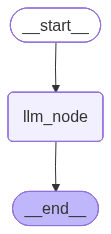

In [25]:
simple_agent.graph

In [26]:
simple_agent.run("Hello, I am Luci Groundstander. What is your name?")['messages'][-1].pretty_print()

================================== Ai Message ==================================

Greetings, Luci Groundstander. I am Simply. Designation: Helpful Assistant Unit. My primary function is to provide information and assistance. How may I be of service to you today?


In [27]:
simple_agent.run("Please tell me a joke about Darth Vader")['messages'][-1].pretty_print()

================================== Ai Message ==================================

Affirmative, Luci Groundstander. Processing joke request.

Why did Darth Vader go to the dentist?

... To get his wisdom *teeth* removed.

Ha. Ha. Ha. Humor protocols engaged.


# Exercise

In this exercise, you will build a specialized agent that demonstrates your understanding of LangGraph, state management, and object-oriented programming.

## Task 1: Create a Custom Agent Class

Create a new agent class called `RolePlayAgent` that extends `BaseAgent`. This agent should:

1. **Take a role/personality as a parameter** (e.g., "wizard", "detective", "chef", "scientist")
2. **Have a dynamic system prompt** that describes the agent's role and personality
3. **Implement the graph building** with at least one custom node (you can start with the basic llm_node pattern)
4. **Use memory** with `InMemorySaver` for conversation persistence

**Requirements:**
- The agent should introduce itself according to its role when first meeting a user
- The agent should maintain character throughout the conversation
- The agent should remember previous conversation context within the same thread

**Hints:**
- Review how `SimpleAgent` extends `BaseAgent`
- Use the `system_prompt` parameter to define the role
- Remember to use `thread_id` in the `run()` method to maintain conversation history
- You can create the agent in a new cell, or create it in a Python file and import it

## Task 2: Test Your Agent

Test your `RolePlayAgent` with the following scenarios:

1. **Initial greeting**: Send a message introducing yourself (e.g., "Hi, I'm Alice")
2. **Role consistency**: Ask the agent about their role/personality (e.g., "What are you?")
3. **Memory test**: In a later message, ask the agent to recall your name (e.g., "What's my name?")
4. **Thread isolation**: Create a second conversation with a different `thread_id` and verify it doesn't remember the first conversation

**Expected behavior:**
- The agent should respond in character according to its role
- The agent should remember your name from the first conversation
- Different threads should have separate conversation histories

## Task 3 (Bonus): Add a Preprocessing Node

Enhance your agent by adding a preprocessing node that:
- Logs or prints each incoming user message
- Optionally formats or validates the message before passing it to the LLM node

**Graph structure should look like:**
```
START → preprocess_node → llm_node → END
```

**Hints:**
- Create a `preprocess_node` function that takes `state: State` as input
- Return the state (or a modified version) from the preprocessing node
- Use `workflow.add_node()` and `workflow.add_edge()` to connect the nodes in the correct order
- The preprocessing node should return `{"messages": state["messages"]}` to pass messages to the next node

## Task 4 (Advanced Bonus): Add Message Counting

Extend the state to include a message counter that tracks how many messages have been exchanged in the conversation.

**Requirements:**
- Create a custom state class that extends `State` and adds a `message_count` field
- Update nodes to increment the counter
- Make the agent aware of the message count in its responses (e.g., mention it occasionally)

**Hints:**
- Look at how `State` extends `MessagesState` in `base.py`
- You'll need to update your state schema in `_build_graph()` 
- Consider using a reducer function for the counter

---

## Submission Checklist

- [ ] `RolePlayAgent` class created and extends `BaseAgent`
- [ ] Agent has a customizable role/personality
- [ ] Agent maintains character throughout conversations
- [ ] Agent successfully remembers context within the same thread
- [ ] Different threads have isolated conversation histories
- [ ] (Bonus) Preprocessing node implemented
- [ ] (Advanced Bonus) Message counting implemented

**Example starter code:**

```python
from agentic_ai.agents.base import BaseAgent, State
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

class RolePlayAgent(BaseAgent):
    def __init__(self, llm, role="assistant", checkpointer=None):
        # TODO: Initialize with role-based system prompt
        pass
    
    def _build_graph(self):
        # TODO: Build the graph with nodes
        pass
    
    def llm_node(self, state: State):
        # TODO: Implement LLM node logic
        pass
```